# Training History Visualization
This notebook loads and plots training histories from the output_with_sparsity directory.

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
# Base directory
base_dir = Path("/home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/output/cnn-baseline/output_with_sparsity/cnn_model_iterable_lr_4_batch_512")

# Find all training history files
history_files = list(base_dir.glob("*/seed_23/training_history.pt"))
history_files.sort()

print(f"Found {len(history_files)} training history files:")
for f in history_files:
    print(f"  - {f.parent.parent.name}")

Found 14 training history files:
  - task_1-1
  - task_1-2
  - task_1-3
  - task_2-1
  - task_2-2
  - task_2-3
  - task_3-1
  - task_3-2
  - task_3-3
  - task_4-1
  - task_4-2
  - task_4-3
  - task_4-4
  - task_4-5


In [3]:
# Load all histories
histories = {}
for file_path in history_files:
    task_name = file_path.parent.parent.name
    try:
        history = torch.load(file_path, map_location='cpu')
        histories[task_name] = history
        print(f"Loaded {task_name}: {type(history)}")
        if isinstance(history, dict):
            print(f"  Keys: {list(history.keys())}")
            for key in history.keys():
                if isinstance(history[key], (list, np.ndarray)):
                    print(f"    {key}: length = {len(history[key])}")
    except Exception as e:
        print(f"Error loading {task_name}: {e}")

print(f"\nSuccessfully loaded {len(histories)} training histories")

Error loading task_1-1: PytorchStreamReader failed reading zip archive: invalid header or archive is corrupted
Loaded task_1-2: <class 'dict'>
  Keys: ['step', 'train_loss', 'val_loss', 'lr']
    step: length = 88
    train_loss: length = 88
    val_loss: length = 88
    lr: length = 0
Loaded task_1-3: <class 'dict'>
  Keys: ['step', 'train_loss', 'val_loss', 'lr']
    step: length = 50
    train_loss: length = 50
    val_loss: length = 50
    lr: length = 0
Loaded task_2-1: <class 'dict'>
  Keys: ['step', 'train_loss', 'val_loss', 'lr']
    step: length = 66
    train_loss: length = 66
    val_loss: length = 66
    lr: length = 0
Loaded task_2-2: <class 'dict'>
  Keys: ['step', 'train_loss', 'val_loss', 'lr']
    step: length = 159
    train_loss: length = 159
    val_loss: length = 159
    lr: length = 0
Loaded task_2-3: <class 'dict'>
  Keys: ['step', 'train_loss', 'val_loss', 'lr']
    step: length = 38
    train_loss: length = 38
    val_loss: length = 38
    lr: length = 0
Loaded

## Individual Task Plots
Plot training and validation loss for each task separately.

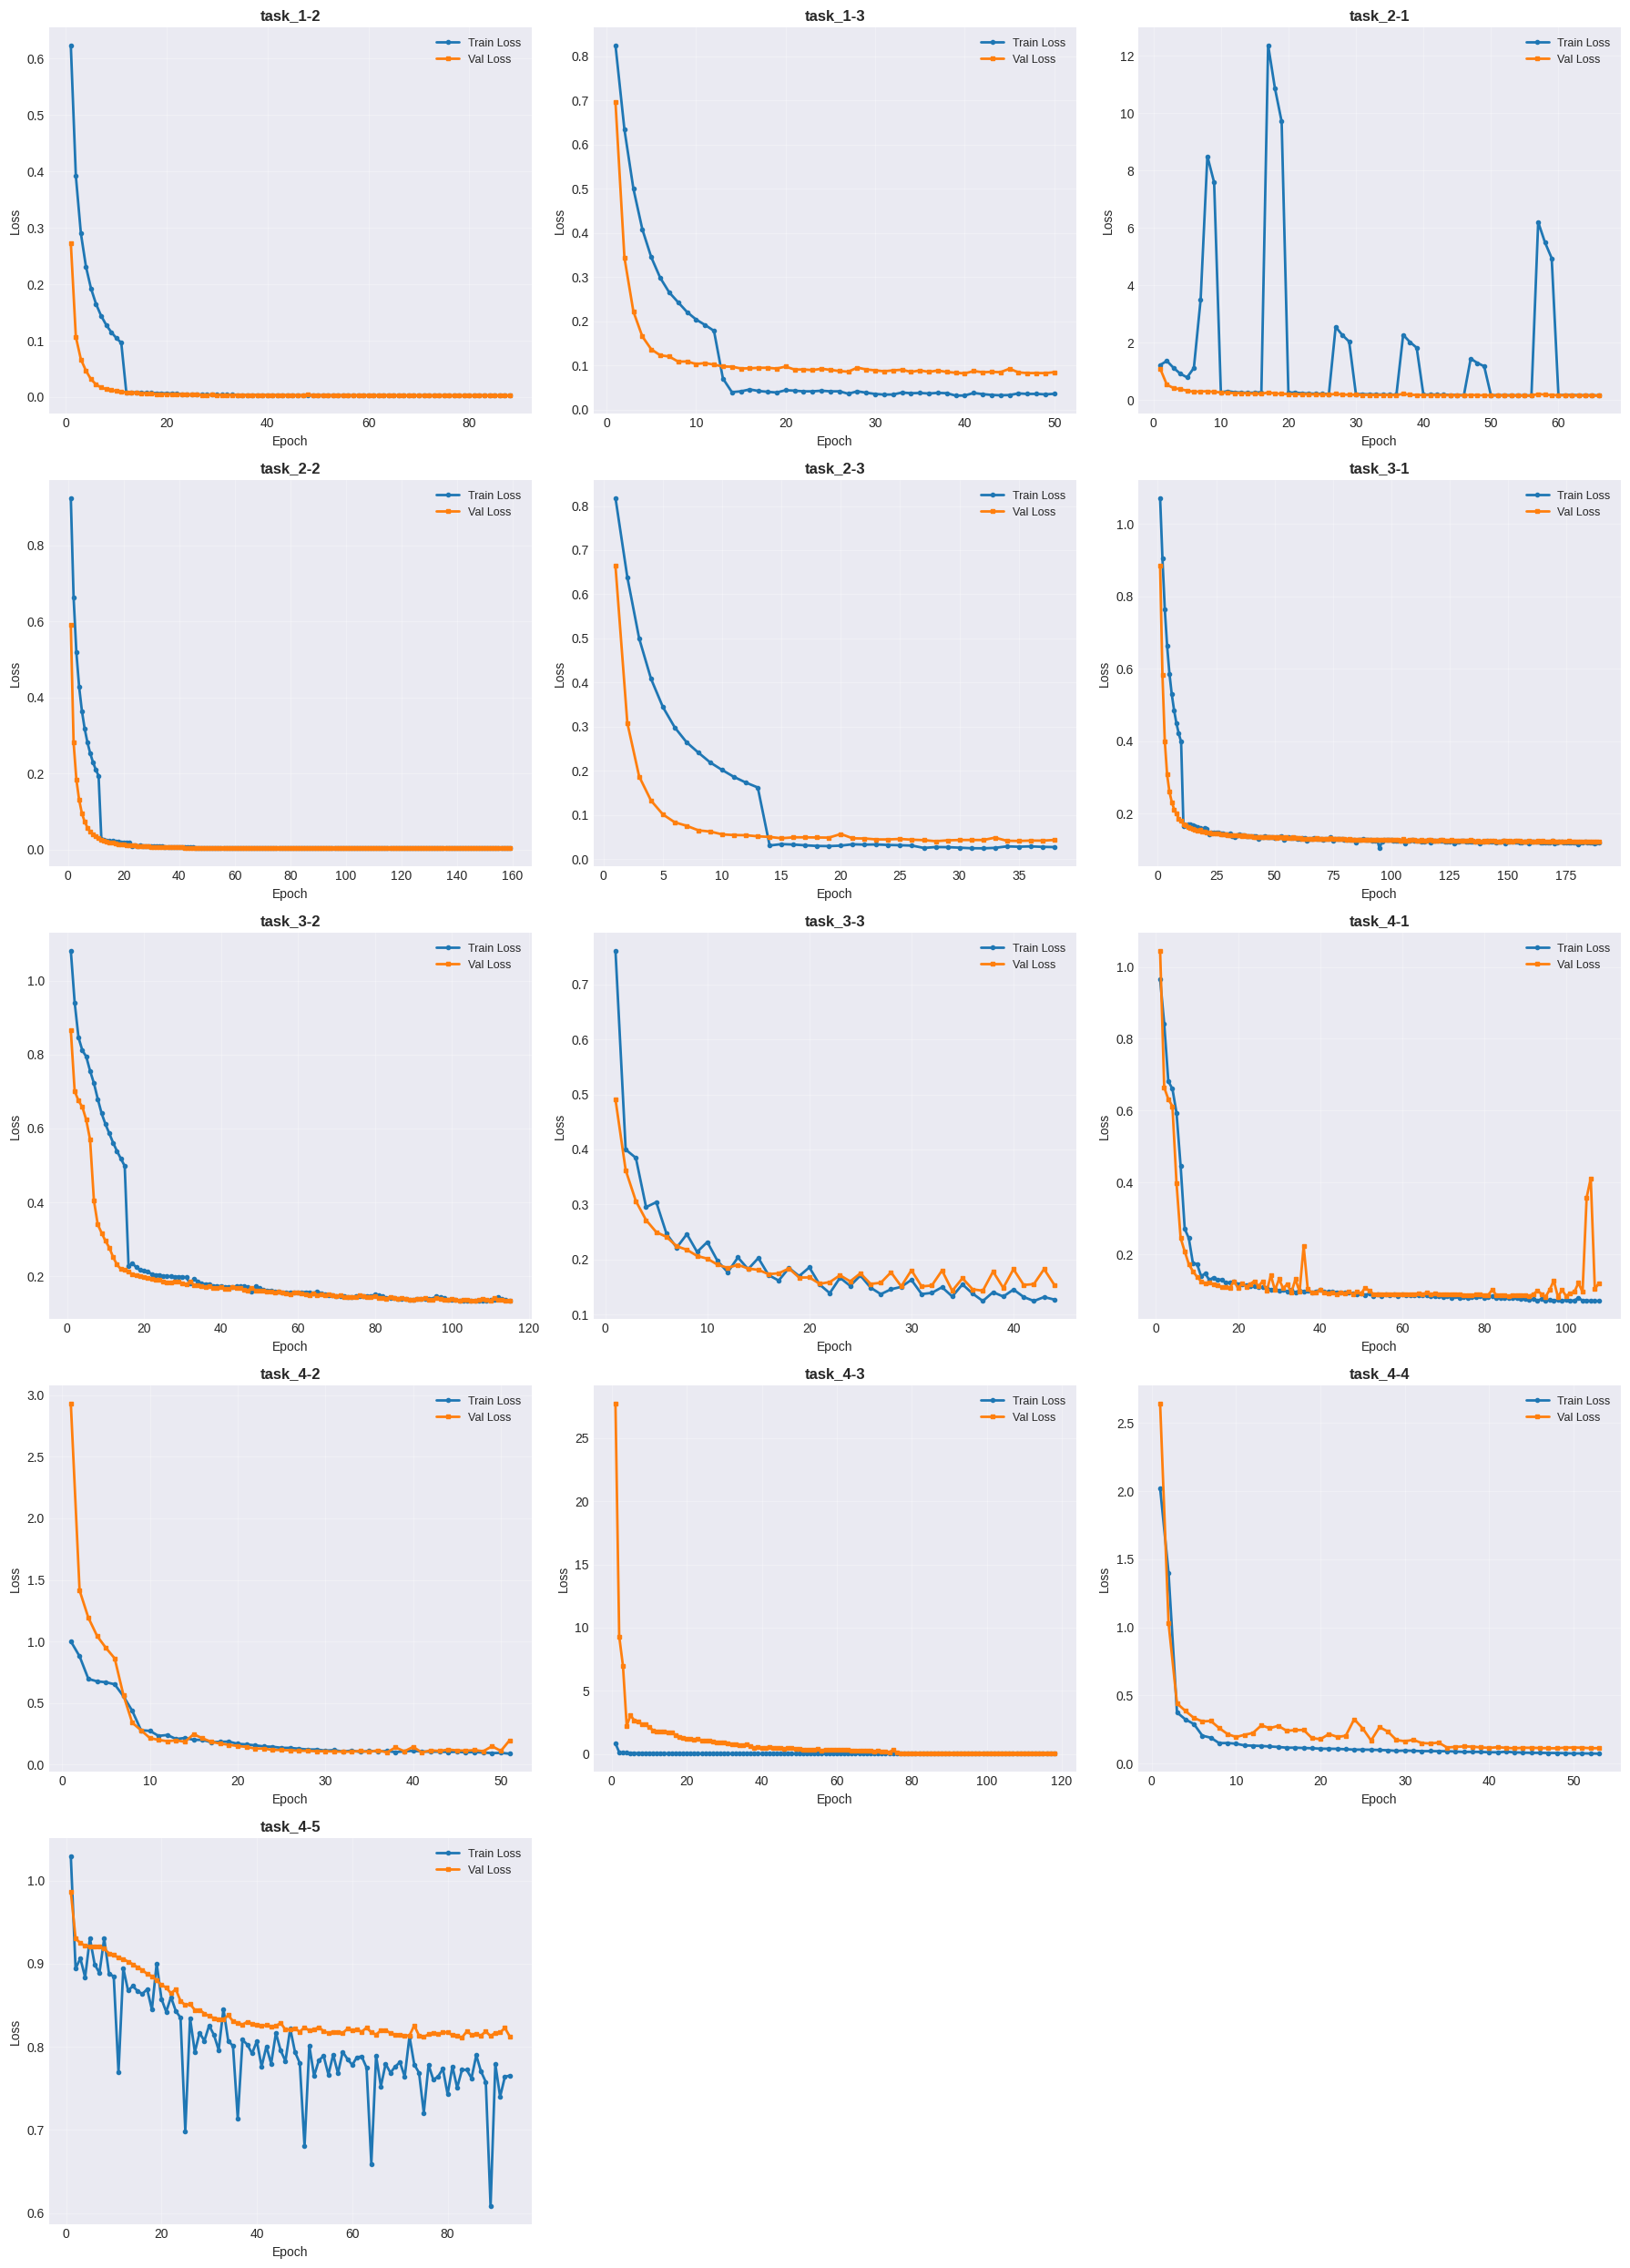

Individual plots saved to: output_with_sparsity/training_history_plots.png


In [4]:
# Create individual plots for each task
n_tasks = len(histories)
n_cols = 3
n_rows = (n_tasks + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

for idx, (task_name, history) in enumerate(sorted(histories.items())):
    ax = axes[idx]
    
    if isinstance(history, dict):
        # Plot training and validation losses
        if 'train_loss' in history:
            epochs = range(1, len(history['train_loss']) + 1)
            ax.plot(epochs, history['train_loss'], label='Train Loss', marker='o', markersize=3, linewidth=2)
        
        if 'val_loss' in history:
            epochs = range(1, len(history['val_loss']) + 1)
            ax.plot(epochs, history['val_loss'], label='Val Loss', marker='s', markersize=3, linewidth=2)
        
        # Check for other possible keys
        for key in history.keys():
            if key not in ['train_loss', 'val_loss'] and 'loss' in key.lower():
                epochs = range(1, len(history[key]) + 1)
                ax.plot(epochs, history[key], label=key, marker='^', markersize=3, linewidth=2)
    
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Loss', fontsize=10)
    ax.set_title(f'{task_name}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(histories), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('output_with_sparsity/training_history_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("Individual plots saved to: output_with_sparsity/training_history_plots.png")

## Combined Plots
Show all tasks together for comparison.

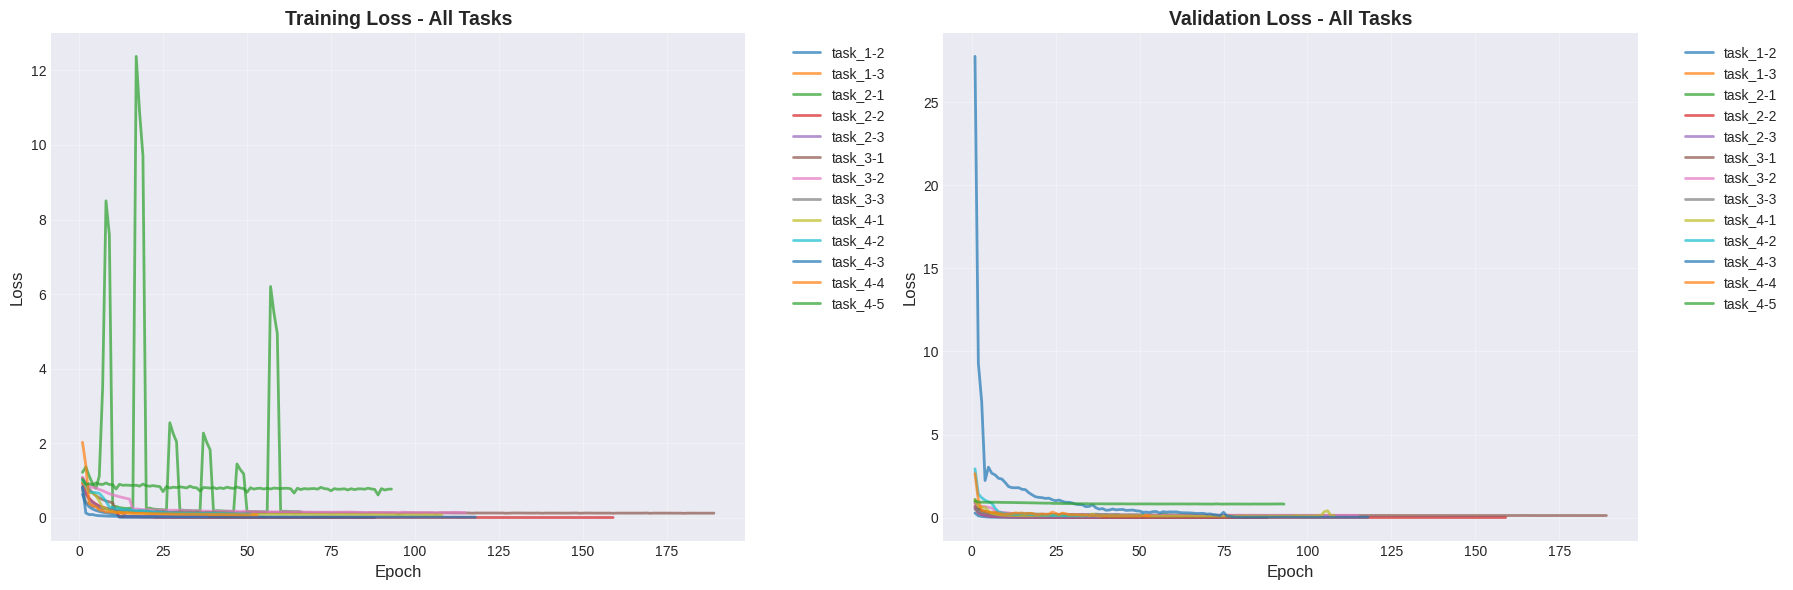

Combined plot saved to: output_with_sparsity/training_history_combined.png


In [5]:
# Create combined plot showing all tasks together
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

for task_name, history in sorted(histories.items()):
    if isinstance(history, dict):
        if 'train_loss' in history:
            epochs = range(1, len(history['train_loss']) + 1)
            ax1.plot(epochs, history['train_loss'], label=task_name, alpha=0.7, linewidth=2)
        
        if 'val_loss' in history:
            epochs = range(1, len(history['val_loss']) + 1)
            ax2.plot(epochs, history['val_loss'], label=task_name, alpha=0.7, linewidth=2)

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training Loss - All Tasks', fontsize=14, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Validation Loss - All Tasks', fontsize=14, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output_with_sparsity/training_history_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print("Combined plot saved to: output_with_sparsity/training_history_combined.png")

## Summary Statistics

In [6]:
# Print summary statistics
print("\n" + "="*80)
print("TRAINING HISTORY SUMMARY")
print("="*80)

for task_name, history in sorted(histories.items()):
    print(f"\n{task_name}:")
    if isinstance(history, dict):
        if 'train_loss' in history:
            train_losses = history['train_loss']
            print(f"  Train Loss - Initial: {train_losses[0]:.6f}, Final: {train_losses[-1]:.6f}, Min: {min(train_losses):.6f}")
        
        if 'val_loss' in history:
            val_losses = history['val_loss']
            print(f"  Val Loss   - Initial: {val_losses[0]:.6f}, Final: {val_losses[-1]:.6f}, Min: {min(val_losses):.6f}")
            print(f"  Best epoch: {np.argmin(val_losses) + 1}")
        
        print(f"  Total epochs: {len(history.get('train_loss', history.get('val_loss', [])))}")


TRAINING HISTORY SUMMARY

task_1-2:
  Train Loss - Initial: 0.624014, Final: 0.002699, Min: 0.002699
  Val Loss   - Initial: 0.273446, Final: 0.002618, Min: 0.002536
  Best epoch: 78
  Total epochs: 88

task_1-3:
  Train Loss - Initial: 0.825457, Final: 0.035782, Min: 0.031626
  Val Loss   - Initial: 0.696557, Final: 0.084686, Min: 0.081964
  Best epoch: 40
  Total epochs: 50

task_2-1:
  Train Loss - Initial: 1.214545, Final: 0.155897, Min: 0.154119
  Val Loss   - Initial: 1.095168, Final: 0.149472, Min: 0.148737
  Best epoch: 56
  Total epochs: 66

task_2-2:
  Train Loss - Initial: 0.925582, Final: 0.003244, Min: 0.003229
  Val Loss   - Initial: 0.591967, Final: 0.003163, Min: 0.003117
  Best epoch: 149
  Total epochs: 159

task_2-3:
  Train Loss - Initial: 0.818508, Final: 0.027197, Min: 0.024421
  Val Loss   - Initial: 0.664293, Final: 0.043393, Min: 0.040560
  Best epoch: 28
  Total epochs: 38

task_3-1:
  Train Loss - Initial: 1.072403, Final: 0.119976, Min: 0.103819
  Val Loss 

## Task Group Analysis
Analyze performance by task groups (1-1, 1-2, etc.)

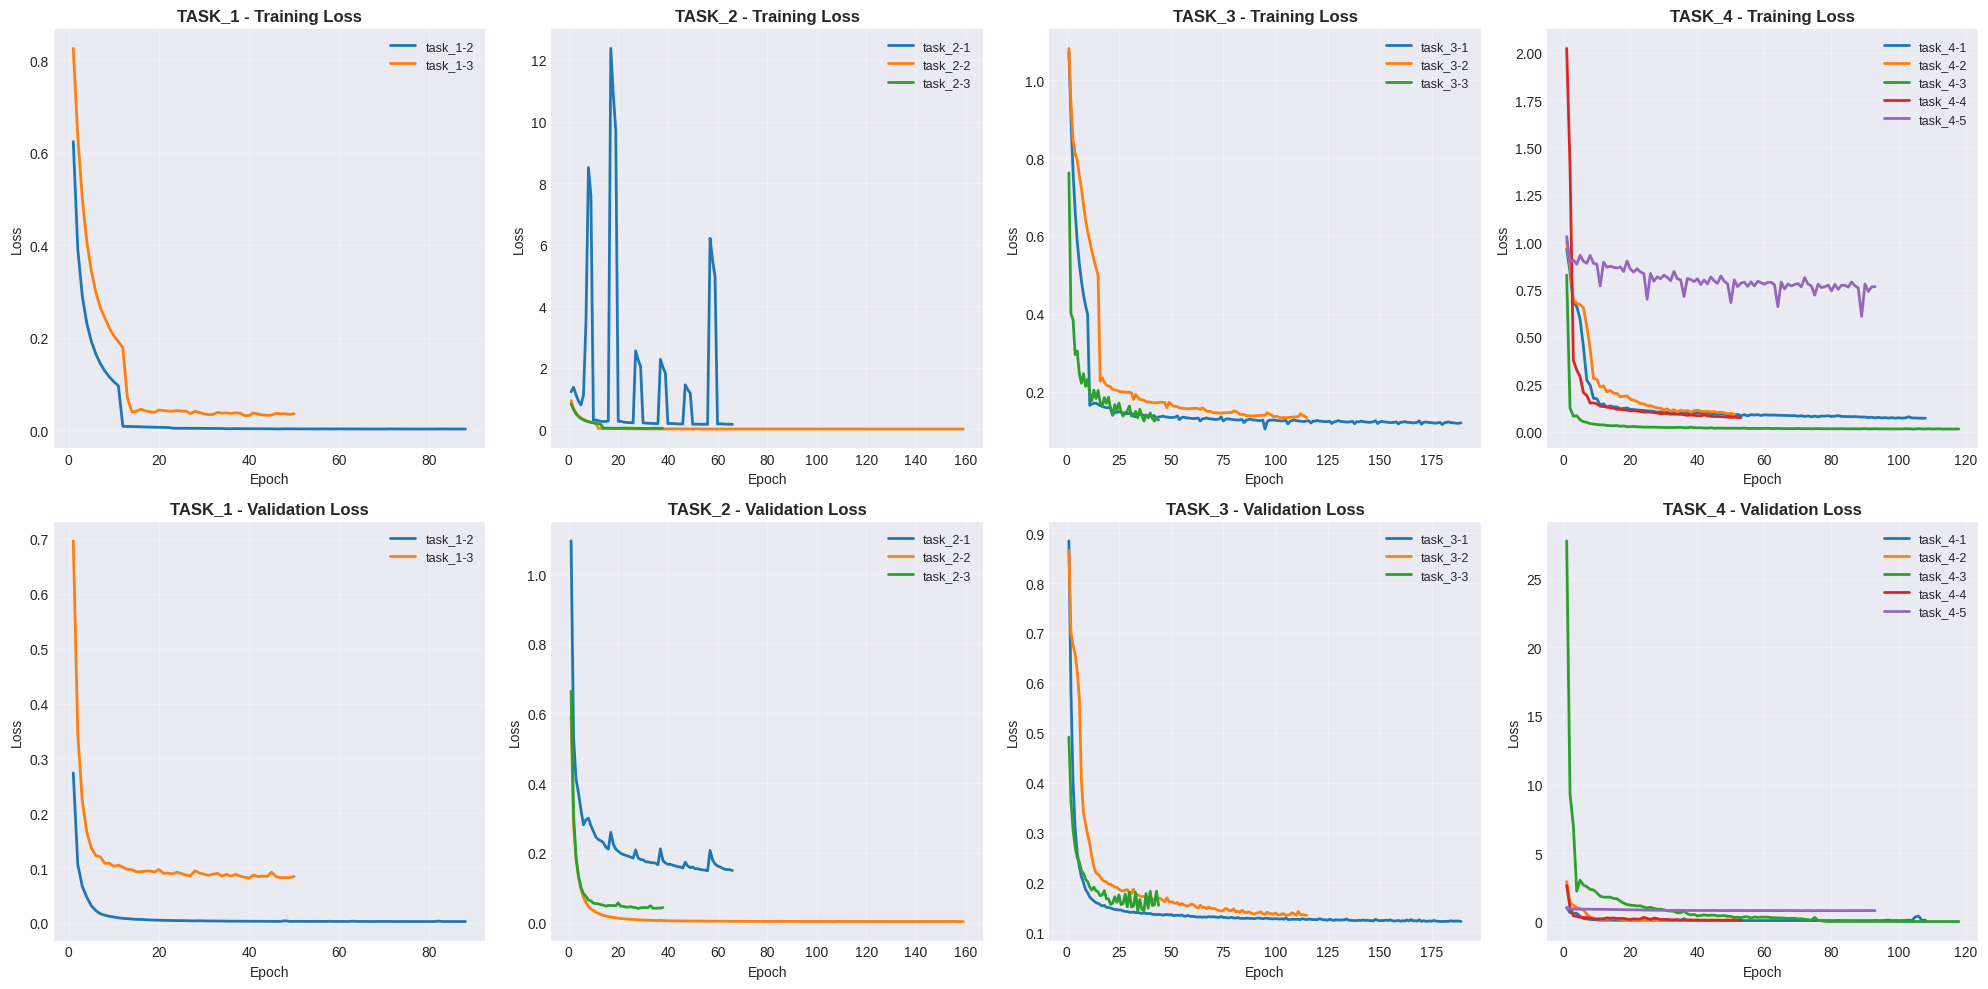

Group plots saved to: output_with_sparsity/training_history_by_groups.png


In [7]:
# Group tasks by category
task_groups = {}
for task_name in histories.keys():
    group = task_name.split('-')[0]  # e.g., 'task_1', 'task_2', etc.
    if group not in task_groups:
        task_groups[group] = []
    task_groups[group].append(task_name)

# Plot by groups
n_groups = len(task_groups)
fig, axes = plt.subplots(2, n_groups, figsize=(5*n_groups, 10))
if n_groups == 1:
    axes = axes.reshape(2, 1)

for idx, (group, tasks) in enumerate(sorted(task_groups.items())):
    ax_train = axes[0, idx]
    ax_val = axes[1, idx]
    
    for task_name in sorted(tasks):
        history = histories[task_name]
        if isinstance(history, dict):
            if 'train_loss' in history:
                epochs = range(1, len(history['train_loss']) + 1)
                ax_train.plot(epochs, history['train_loss'], label=task_name, linewidth=2)
            
            if 'val_loss' in history:
                epochs = range(1, len(history['val_loss']) + 1)
                ax_val.plot(epochs, history['val_loss'], label=task_name, linewidth=2)
    
    ax_train.set_xlabel('Epoch', fontsize=10)
    ax_train.set_ylabel('Loss', fontsize=10)
    ax_train.set_title(f'{group.upper()} - Training Loss', fontsize=12, fontweight='bold')
    ax_train.legend(fontsize=9)
    ax_train.grid(True, alpha=0.3)
    
    ax_val.set_xlabel('Epoch', fontsize=10)
    ax_val.set_ylabel('Loss', fontsize=10)
    ax_val.set_title(f'{group.upper()} - Validation Loss', fontsize=12, fontweight='bold')
    ax_val.legend(fontsize=9)
    ax_val.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output_with_sparsity/training_history_by_groups.png', dpi=150, bbox_inches='tight')
plt.show()

print("Group plots saved to: output_with_sparsity/training_history_by_groups.png")